In [ ]:
!mkdir stage1
!mkdir stage2

!unzip /content/model_and_metrics_embeddings_layer_pooler_finetuning_stage1.zip -d stage1
!unzip /content/model_and_metrics_embeddings_layer_pooler_finetuning_stage2.zip -d stage2

Archive:  /content/model_and_metrics_embeddings_layer_pooler_finetuning_stage1.zip
  inflating: stage1/metrics_1/train_losses.txt  
  inflating: stage1/metrics_1/val_losses.txt  
  inflating: stage1/metrics_1/val_rmses.txt  
  inflating: stage1/metrics_1/train_rmses.txt  
  inflating: stage1/model_checkpoints_1/best_checkpoint.pt  
  inflating: stage1/model_checkpoints_1/best_checkpoint_pooler.pt  
  inflating: stage1/model_checkpoints_1/best_checkpoint_layer23.pt  
Archive:  /content/model_and_metrics_embeddings_layer_pooler_finetuning_stage2.zip
  inflating: stage2/metrics_1/train_losses.txt  
  inflating: stage2/metrics_1/val_losses.txt  
  inflating: stage2/metrics_1/val_rmses.txt  
  inflating: stage2/metrics_1/train_rmses.txt  
  inflating: stage2/metrics_finetuning_head_2/train_losses.txt  
  inflating: stage2/metrics_finetuning_head_2/val_losses.txt  
  inflating: stage2/metrics_finetuning_head_2/val_rmses.txt  
  inflating: stage2/metrics_finetuning_head_2/train_rmses.txt  
  

# Ноутбук 1

В данном ноутбуке используем эмбеддинги модели ai-forever/ru-en-RoSBERTa.

Приведено в чистоту: цикл обучения приведен к одному общему коду, оптимизаторы и лоссы аналогично всюду свои с передачей своего списка обучаемых параметров

In [ ]:
pip install transformers sentence-transformers

# Загрузка модели



In [ ]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("ai-forever/ru-en-RoSBERTa")

sbert_model = AutoModel.from_pretrained("ai-forever/ru-en-RoSBERTa")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/715 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/958 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.61G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: ai-forever/ru-en-RoSBERTa
Key                 | Status  | 
--------------------+---------+-
pooler.dense.bias   | MISSING | 
pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import pandas as pd
import numpy as np

# Create a Pandas DataFrame
df = pd.read_csv('/content/offers_data_numalphareduced.csv') #.iloc[:64, :] # для проверки на CPU

df.rename(columns = {'p_full_description': 'description'}, inplace=True)

df.head()


,shareUrl,author_category,author_organization,full_description,region,description,price_value,price_value_m2,price_value_m2_ls
0,https://realty.yandex.ru/offer/522753573506055...,AGENCY,Петербургская Недвижимость,Номер объявления: 20590 - назовите его операто...,Nevsky,номер объявления: двадцать тысяч пятьсот девян...,13500000.0,413476.263400,413476.263400
1,https://realty.yandex.ru/offer/522692674778749...,DEVELOPER,Группа компаний ФСК,Цена со скидкой до 30% в прямой продаже от зас...,Nevsky,цена со скидкой до тридцать% в прямой продаже ...,7520853.0,211855.014085,211855.014085
2,https://realty.yandex.ru/offer/419286373934393...,DEVELOPER,ООО «ЛСР. Недвижимость–Северо-Запад»,Продается 1-комнатная квартира в ЖК «Октябрьск...,Nevsky,продается однокомнатная квартира в жилой компл...,12298650.0,331500.000000,331500.000000
3,https://realty.yandex.ru/offer/638098898688737...,AGENCY,NaN,Продаётся просторная 1к квартира по адресу ул....,Nevsky,продаётся просторная 1к квартира по адресу ул....,8050000.0,208010.335917,208010.335917
4,https://realty.yandex.ru/offer/490856214913453222,DEVELOPER,Петербургская Недвижимость,Продается уютная 1-комнатная квартира от застр...,Nevsky,продается уютная однокомнатная квартира от зас...,12500019.0,387838.008067,387838.008067


## Формирование эмбеддингов модели + целевая переменная

In [ ]:
descriptions = df['description'].tolist()
prices = (df['price_value']/1e6).tolist()

In [ ]:
texts_tokens_masks = tokenizer(descriptions, padding=True, max_length=256,
                               truncation=True, return_tensors='pt',
                          )

texts_tokens = texts_tokens_masks['input_ids']
texts_masks = texts_tokens_masks['attention_mask']

## Разбиваем на обучающую, тестовую и валидационную выборки

Разбиваем обучающую на две части (применим для файнтюнинга)

Train: 70%, test и val 60% к 40% оставшегося

In [ ]:
#train-test-val split
from sklearn.model_selection import train_test_split

idx_train, idx_test_val = train_test_split(list(range(len(descriptions))), random_state=42, test_size=0.3)

idx_val, idx_test = train_test_split(idx_test_val, random_state=42, test_size=0.6)

idx_train_ft, idx_train_2nd = train_test_split(idx_train, random_state=42, test_size=0.7)


# разбиваем трейн на две части, для файнтюнинга и для дообучения головы после файнтюнинга


In [ ]:
def cut_data_by_idx(idx, *data_lists):
  res = []
  for data in data_lists:
    res.append([data[i] for i in idx])
  return tuple(res)

In [ ]:
train_tk, train_ms, train_prices = cut_data_by_idx(idx_train_ft, texts_tokens, texts_masks, prices)

train_full_tk, train_full_ms, train_full_prices = cut_data_by_idx(idx_train, texts_tokens, texts_masks, prices)


val_tk, val_ms, val_prices = cut_data_by_idx(idx_val, texts_tokens, texts_masks, prices)
test_tk, test_ms, test_prices = cut_data_by_idx(idx_test, texts_tokens, texts_masks, prices)

In [ ]:
len(train_tk)

2139

## Адаптация под Dataset и DataLoader


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class PriceDataset(Dataset):
    def __init__(self, tokens, masks, prices):
        self.tokens = tokens
        self.masks = masks

        self.prices = torch.tensor(prices, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.prices)

    def __getitem__(self, idx):
        return self.tokens[idx], self.masks[idx], self.prices[idx]


train_dataset = PriceDataset(np.array(train_tk), np.array(train_ms), np.array(train_prices))
val_dataset = PriceDataset(np.array(val_tk), np.array(val_ms),  np.array(val_prices))
test_dataset = PriceDataset(np.array(test_tk), np.array(test_ms),  np.array(test_prices))

train_full_dataset = PriceDataset(np.array(train_full_tk), np.array(train_full_ms), np.array(train_full_prices))

batch_size = 32

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=False)

train_dataloader_nonshuffled = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

train_dataloader_full = DataLoader(train_full_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=False)

print(f"DataLoader created with batch size {batch_size}. It will yield {len(train_dataloader)} batches.")

# Verify a batch
for token, mask, price in train_dataloader:
    print(f"Sample batch - token shape: {token.shape}, Prices shape: {price.shape}")
    break

DataLoader created with batch size 32. It will yield 67 batches.
Sample batch - token shape: torch.Size([32, 256]), Prices shape: torch.Size([32, 1])


## Реализация класса
### Здесь рассматриваем сразу на готовых эмбеддингах

In [ ]:
sbert_model[0].auto_model

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(120138, 1024, padding_idx=0)
    (position_embeddings): Embedding(512, 1024)
    (token_type_embeddings): Embedding(2, 1024)
    (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-23): 24 x BertLayer(
        (attention): BertAttention(
          (self): BertSdpaSelfAttention(
            (query): Linear(in_features=1024, out_features=1024, bias=True)
            (key): Linear(in_features=1024, out_features=1024, bias=True)
            (value): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=1024, out_features=1024, bias=True)
            (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1,

In [ ]:
for name, e in sbert_model.named_parameters():
  print(name)

0.auto_model.embeddings.word_embeddings.weight
0.auto_model.embeddings.position_embeddings.weight
0.auto_model.embeddings.token_type_embeddings.weight
0.auto_model.embeddings.LayerNorm.weight
0.auto_model.embeddings.LayerNorm.bias
0.auto_model.encoder.layer.0.attention.self.query.weight
0.auto_model.encoder.layer.0.attention.self.query.bias
0.auto_model.encoder.layer.0.attention.self.key.weight
0.auto_model.encoder.layer.0.attention.self.key.bias
0.auto_model.encoder.layer.0.attention.self.value.weight
0.auto_model.encoder.layer.0.attention.self.value.bias
0.auto_model.encoder.layer.0.attention.output.dense.weight
0.auto_model.encoder.layer.0.attention.output.dense.bias
0.auto_model.encoder.layer.0.attention.output.LayerNorm.weight
0.auto_model.encoder.layer.0.attention.output.LayerNorm.bias
0.auto_model.encoder.layer.0.intermediate.dense.weight
0.auto_model.encoder.layer.0.intermediate.dense.bias
0.auto_model.encoder.layer.0.output.dense.weight
0.auto_model.encoder.layer.0.output.dens

In [ ]:
import torch.nn as nn
from collections import OrderedDict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Define a custom PyTorch model class
class SBERTRegressor_finetuning(nn.Module):
    def __init__(self, sbert_model, n_trainable_layers=0):
        super().__init__()

        #self.input_tokenizer =

        self.encoder_n_layers = len(sbert_model.encoder.layer)
        self.n_trainable_layers = n_trainable_layers

        self.sbert_model = sbert_model.to(device)

        # Freeze the parameters of the SBERT model
        for param in self.sbert_model.embeddings.parameters():
            param.requires_grad = False

        for i, layer in enumerate(self.sbert_model.encoder.layer):
          for param in layer.parameters():
              param.requires_grad = (i >= self.encoder_n_layers-self.n_trainable_layers)

        for param in self.sbert_model.pooler.parameters():
            param.requires_grad = True

        self.hidden_layer_neurons = 256
        self.activation = nn.Sigmoid()

        self.regression_head = nn.Sequential(
                      OrderedDict([
                          ('regression_head1', nn.Linear(1024, self.hidden_layer_neurons)),
                          ('aciv1', self.activation),
                          ('regression_head2', nn.Linear(self.hidden_layer_neurons, 1))
                      ])
                  )

    def get_pooler_parameters(self):
      return self.sbert_model.pooler.parameters()

    def get_trainable_encoder_layers_parameters(self):
      output = {}
      for i in range(self.encoder_n_layers-self.n_trainable_layers, self.encoder_n_layers):
        output[i] = self.sbert_model.encoder.layer[i].parameters()

      return output

    def pool(self, x, mask, pooling_method="cls"):
      if pooling_method == "mean":
          s = torch.sum(x * mask.unsqueeze(-1).float(), dim=1)
          d = mask.sum(axis=1, keepdim=True).float()
          return s / d
      elif pooling_method == "cls":
          return x[:, 0]


    def forward(self, tokens, masks):
        # The input embeddings_x are already generated by the SBERT model
        # Pass the input embeddings directly to the regression head
        #embeddings_x = self.sbert_model(x) #<-этот этап пропускаем по изначальному построению -- encode выполнили выше
        out = self.sbert_model(**{'input_ids': tokens, 'attention_mask': masks})['last_hidden_state']
        embeddings_x = self.pool(out, masks, 'mean')
        res = nn.functional.normalize(embeddings_x)
        res = self.regression_head(res)


        return res

    def get_embeddings(self, loader, device):
      train_embeddings = None
      self.eval() # Set model to evaluation mode

      train_targets = []


      with torch.no_grad(): # Disable gradient calculations
          for batch_tk, batch_ms, batch_prices in tqdm(loader):
              batch_tk = batch_tk.to(device)
              batch_ms = batch_ms.to(device)
              batch_prices = batch_prices.to(device)

              outputs = self.sbert_model(batch_tk, batch_ms).last_hidden_state #.pooler_output
              embeddings_x = self.pool(outputs, batch_ms, 'mean')
              outputs = embeddings_x
                #правка

              if train_embeddings is None:
                train_embeddings = outputs.cpu().numpy()
              else:
                train_embeddings = np.vstack([train_embeddings, outputs.cpu().numpy()])

              train_targets.extend(batch_prices.cpu().numpy())
      return train_embeddings, train_targets

    def upload_checkpoint(self, path, device):
      self.regression_head.load_state_dict(torch.load(path, map_location=device))

      pooler_path = f"{path[:-3]}_pooler.pt"
      self.sbert_model.pooler.load_state_dict(torch.load(pooler_path, map_location=device))

      if self.n_trainable_layers > 0:
        trainable_layers_path = []
        for i in range(self.n_trainable_layers):
          path_i = f"{path[:-3]}_layer{self.encoder_n_layers-i-1}.pt"

          self.sbert_model.encoder.layer[self.encoder_n_layers-i-1].load_state_dict(torch.load(path_i, map_location=device))


    def save_checkpoint(self, path):

      pooler_path = f"{path[:-3]}_pooler.pt"
      torch.save(self.sbert_model.pooler.state_dict(), pooler_path)
      torch.save(self.regression_head.state_dict(), path)

      if self.n_trainable_layers > 0:
        trainable_layers_path = []
        for i in range(self.n_trainable_layers):
          path_i = f"{path[:-3]}_layer{self.encoder_n_layers-i-1}.pt"
          torch.save(self.sbert_model.encoder.layer[self.encoder_n_layers-i-1].state_dict(),
                     path_i)


      print(f'savepath: {path}')

print("SBERTRegressor model class defined successfully.")

# Instantiate the model
#model = SBERTRegressor_finetuning(sbert_model)


SBERTRegressor model class defined successfully.


## Обучение


### Целевая функция, обучаемые параметры и оптимизатор



In [ ]:
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler # Import for potential scheduler usage

# 1. Define the loss function (Mean Squared Error for regression)
criterion = nn.MSELoss()

# 2. Define the optimizer (Adam)

model = SBERTRegressor_finetuning(sbert_model, n_trainable_layers=1)

base_learning_rate = 0.001
decayed_learning_rate = 0.0001 # Initial lower LR for "decayed" groups

# Separate parameters into groups
regression_head_params = []
pooler_params = []
encoder_layer_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        if "regression_head" in name:
            regression_head_params.append(param)
        elif "pooler" in name:
            pooler_params.append(param)
        elif "encoder.layer" in name and param.requires_grad:
            encoder_layer_params.append(param)

# Check if any group is empty (optional, for debugging)
if not regression_head_params:
    print("Warning: No trainable parameters found for regression_head.")
if not pooler_params:
    print("Warning: No trainable parameters found for pooler.")
if not encoder_layer_params and model.n_trainable_layers > 0:
    print(f"Warning: No trainable parameters found for specified encoder layers (n_trainable_layers={model.n_trainable_layers}).")

# Create parameter groups for the optimizer
# Assign base_learning_rate to regression_head (constant)
# Assign decayed_learning_rate to pooler and encoder layers
optimizer_param_groups = [
    {'params': regression_head_params, 'lr': base_learning_rate, 'name': 'regression_head'},
    {'params': pooler_params, 'lr': base_learning_rate, 'name': 'pooler'},
    {'params': encoder_layer_params, 'lr': decayed_learning_rate, 'name': 'encoder_layers'}
]

optimizer = optim.Adam(optimizer_param_groups)

# 3. Configure the device (CPU/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Optimizer configured with separate initial learning rates for parameter groups.")
print("Note: Learning rates will remain fixed at these initial values as no dynamic scheduler is applied.")

Optimizer configured with separate initial learning rates for parameter groups.
Note: Learning rates will remain fixed at these initial values as no dynamic scheduler is applied.


In [ ]:
for name, param in model.named_parameters():
   if param.requires_grad:
    print(name)

sbert_model.encoder.layer.23.attention.self.query.weight
sbert_model.encoder.layer.23.attention.self.query.bias
sbert_model.encoder.layer.23.attention.self.key.weight
sbert_model.encoder.layer.23.attention.self.key.bias
sbert_model.encoder.layer.23.attention.self.value.weight
sbert_model.encoder.layer.23.attention.self.value.bias
sbert_model.encoder.layer.23.attention.output.dense.weight
sbert_model.encoder.layer.23.attention.output.dense.bias
sbert_model.encoder.layer.23.attention.output.LayerNorm.weight
sbert_model.encoder.layer.23.attention.output.LayerNorm.bias
sbert_model.encoder.layer.23.intermediate.dense.weight
sbert_model.encoder.layer.23.intermediate.dense.bias
sbert_model.encoder.layer.23.output.dense.weight
sbert_model.encoder.layer.23.output.dense.bias
sbert_model.encoder.layer.23.output.LayerNorm.weight
sbert_model.encoder.layer.23.output.LayerNorm.bias
sbert_model.pooler.dense.weight
sbert_model.pooler.dense.bias
regression_head.regression_head1.weight
regression_head.re

## Алгоритм обучения


In [ ]:
samples_dict = {'train': train_dataloader, 'val': val_dataloader, 'test': test_dataloader}

In [ ]:
import math
import os
import numpy as np # Import numpy for saving arrays efficiently
from IPython.display import clear_output
from tqdm import tqdm


def training_loop(model, samples_dict, criterion, optimizer, n_epochs, metrics_save_path,
                  checkpoint_save_path, scheduler=None,negative_values_penalty=0.1):

  train_losses = []
  val_losses = []
  train_rmses = []
  val_rmses = []

  best_val_loss = float('inf')
  best_rmse = float('inf')

  backward_pass_freq = 5

  output_best_line=""

  for epoch in range(num_epochs):
      # Training loop
      model.train() # Set model to training mode
      total_train_loss = 0
      total_train_rmse = 0
      for i, (batch_tk, batch_ms, batch_prices) in enumerate(tqdm(samples_dict['train'])):
          batch_tk = batch_tk.to(device)
          batch_ms = batch_ms.to(device)
          batch_prices = batch_prices.to(device)

          optimizer.zero_grad() # Zero the gradients
          outputs = model(batch_tk, batch_ms) # Forward pass

          # Штрафуем за отрицательные предсказания
          negative_mask = (outputs < 0).float()
          penalty = negative_values_penalty * outputs**2*negative_mask #negative predictions penalty


          loss = criterion(outputs, batch_prices) + penalty.mean()

          loss = loss / backward_pass_freq
          loss.backward() # Backward pass

          if (i + 1) % backward_pass_freq == 0 or (i + 1) == len(samples_dict['train']): # Perform optimizer step every `backward_pass_freq` batches or at the end of epoch
              optimizer.step() # Update weights
              optimizer.zero_grad() # Zero the gradients for the next accumulation cycle

          total_train_loss += loss.item() * backward_pass_freq # Rescale loss for logging purposes
          total_train_rmse += torch.sqrt(loss * backward_pass_freq).item()

          #total_train_loss += (loss.item()-penalty.mean().item())
          total_train_loss+=loss.item()
          # Calculate RMSE. Since loss is MSE, sqrt(loss) is RMSE for that batch
          #total_train_rmse += torch.sqrt(loss-penalty.mean()).item() # Use torch.sqrt(loss).item() to get RMSE per batch

          total_train_rmse += torch.sqrt(loss).item()

      avg_train_loss = total_train_loss / len(samples_dict['train'])
      avg_train_rmse = total_train_rmse / len(samples_dict['train'])
      train_losses.append(avg_train_loss)
      train_rmses.append(avg_train_rmse)


      model.eval()
      total_val_loss = 0
      total_val_rmse = 0
      with torch.no_grad(): # Disable gradient calculations
          for batch_tk, batch_ms, batch_prices in samples_dict['val']:
              batch_tk = batch_tk.to(device)
              batch_ms = batch_ms.to(device)
              batch_prices = batch_prices.to(device)

              outputs = model(batch_tk, batch_ms) # Forward pass
              loss = criterion(outputs, batch_prices) # Calculate loss

              total_val_loss += loss.item()
              total_val_rmse += torch.sqrt(loss).item() # Use torch.sqrt(loss).item() to get RMSE per batch

      avg_val_loss = total_val_loss / len(samples_dict['val'])
      avg_val_rmse = total_val_rmse / len(samples_dict['val'])
      val_losses.append(avg_val_loss)
      val_rmses.append(avg_val_rmse)

      # Step the learning rate scheduler
      if scheduler is not None:
        scheduler.step(avg_val_loss) # Pass validation loss to the scheduler

      clear_output(wait=True)
      print(f"Epoch {epoch+1}/{num_epochs}: Train Loss: {avg_train_loss:.4f}, Train RMSE: {avg_train_rmse:.4f} | Val Loss: {avg_val_loss:.4f}, Val RMSE: {avg_val_rmse:.4f}")

      # Save the best model checkpoint
      if avg_val_loss < best_val_loss:
          best_val_loss = avg_val_loss
          best_rmse = avg_val_rmse
          checkpoint_path = os.path.join(checkpoint_dir, "best_checkpoint.pt")

          model.save_checkpoint(checkpoint_path)

          print(f"  --> Saved best regression head checkpoint to {checkpoint_path} with Val Loss: {best_val_loss:.4f}")
      print(f"Best Epoch Val Loss: {best_val_loss:.4f}, Val RMSE: {best_rmse:.4f}")

  print("Training finished.")

  # Save metrics to files


  np.savetxt(os.path.join(metrics_save_path, "train_losses.txt"), train_losses)
  np.savetxt(os.path.join(metrics_save_path, "val_losses.txt"), val_losses)
  np.savetxt(os.path.join(metrics_save_path, "train_rmses.txt"), train_rmses)
  np.savetxt(os.path.join(metrics_save_path, "val_rmses.txt"), val_rmses)

  print(f"Training metrics saved to '{metrics_dir}' folder.")

### Обучаем 1-ый вариант с однослойной головой

In [ ]:
checkpoint_dir = "model_checkpoints_1"
os.makedirs(checkpoint_dir, exist_ok=True)

In [ ]:
!touch ./model_checkpoints_1/

In [ ]:
num_epochs = 20

checkpoint_dir = "model_checkpoints_1"
os.makedirs(checkpoint_dir, exist_ok=True)

metrics_dir = "metrics_1"
os.makedirs(metrics_dir, exist_ok=True)
model.to(device)
training_loop(model, samples_dict, criterion, optimizer, num_epochs, f'./{metrics_dir}',
                  f'./{checkpoint_dir}', negative_values_penalty=10)

Epoch 20/20: Train Loss: 1924.5501, Train RMSE: 48.2184 | Val Loss: 990.7299, Val RMSE: 27.6588
savepath: model_checkpoints_1/best_checkpoint.pt
  --> Saved best regression head checkpoint to model_checkpoints_1/best_checkpoint.pt with Val Loss: 990.7299
Best Epoch Val Loss: 990.7299, Val RMSE: 27.6588
Training finished.
Training metrics saved to 'metrics_1' folder.


In [ ]:
import os

model.upload_checkpoint(f'./model_checkpoints_1/best_checkpoint.pt', device=device)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
# Set the model to evaluation mode after loading weights
model.eval()
print("Model set to evaluation mode.")

Model set to evaluation mode.


In [ ]:
#test_evaluation

def assess_test(model, test_loader, device):

  model.eval() # Set model to evaluation mode
  total_test_loss = 0
  total_test_rmse = 0

  all_predictions = []
  all_targets = []


  with torch.no_grad(): # Disable gradient calculations
      for batch_tk, batch_ms, batch_prices in tqdm(test_loader):
          batch_tk = batch_tk.to(device)
          batch_ms = batch_ms.to(device)
          batch_prices = batch_prices.to(device)

          outputs = model(batch_tk, batch_ms)
          loss = criterion(outputs, batch_prices) # Calculate loss

          total_test_loss += loss.item()
          total_test_rmse += torch.sqrt(loss).item()

          all_predictions.extend(outputs.cpu().numpy())
          all_targets.extend(batch_prices.cpu().numpy())

  avg_test_loss = total_test_loss / len(test_loader)
  avg_test_rmse = total_test_rmse / len(test_loader)

  return avg_test_loss, avg_test_rmse, {'predictions': all_predictions, 'targets': all_targets}

avg_test_loss, avg_test_rmse, model_test_res = assess_test(model, samples_dict['test'], device=device)
avg_test_loss, avg_test_rmse

100%|██████████| 58/58 [01:22<00:00,  1.42s/it]


(1628.535602470924, 33.990350599946645)

In [ ]:
a, b = model_test_res['predictions'][:20], model_test_res['targets'][:20]

In [ ]:
np.vstack([np.array(a)[:, 0], np.array(b)[:, 0]])

array([[ 41.147995 ,  15.1491785,  21.291815 ,  20.725592 ,  16.552305 ,
         15.806039 ,  41.327206 ,  41.327053 ,  18.904953 ,  33.322403 ,
         28.760803 ,  41.327255 ,  17.660769 ,  15.078074 ,  19.148315 ,
         26.06324  ,  21.37323  ,  13.668319 ,  18.314342 ,  28.55915  ],
       [ 72.040405 ,  14.864864 ,  10.9368   ,  22.       ,  15.823839 ,
         15.       ,  19.76522  ,  71.933395 ,  14.9      ,  25.35     ,
         40.662    , 407.20822  ,   8.15     ,  24.9      ,   7.65     ,
         23.96     ,  24.       ,   7.5      ,  45.       ,  27.2      ]],
      dtype=float32)

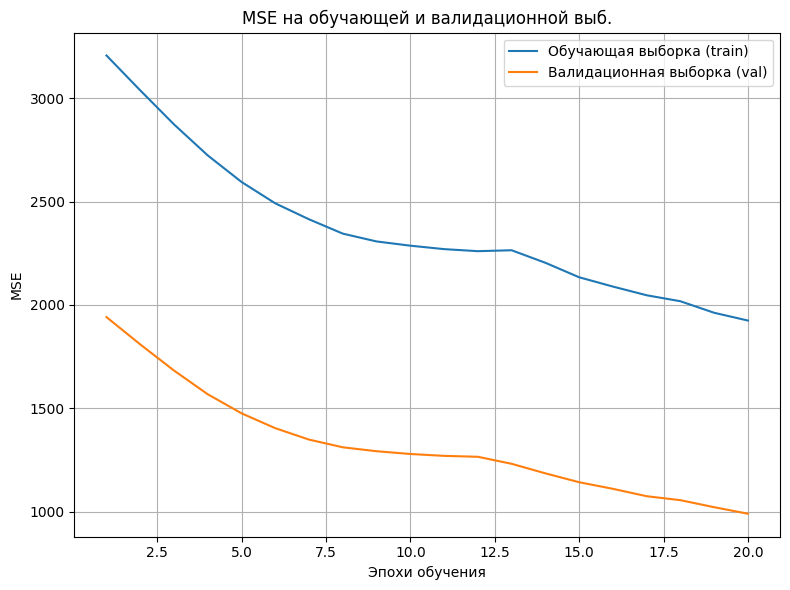

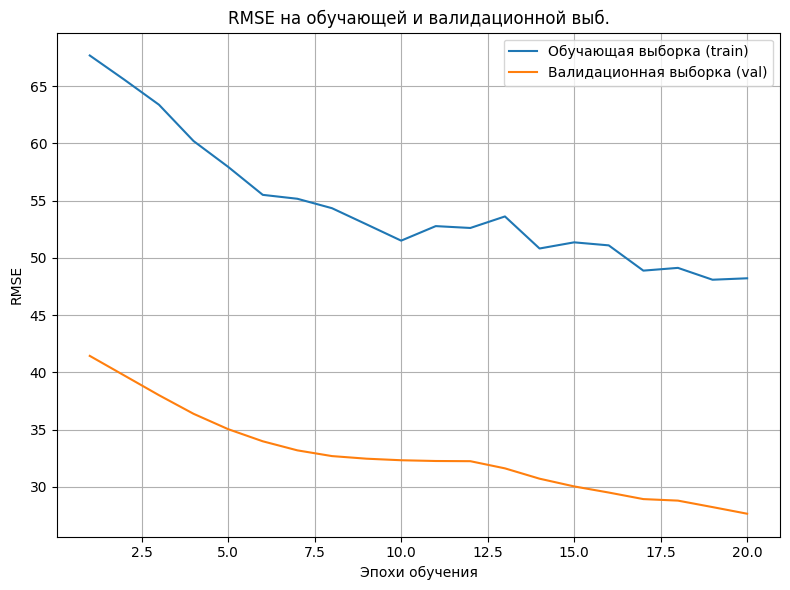

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

# Load the saved metrics

def plot_metrics(folder):
  train_losses = np.loadtxt(os.path.join(folder, "train_losses.txt"))
  val_losses = np.loadtxt(os.path.join(folder, "val_losses.txt"))
  train_rmses = np.loadtxt(os.path.join(folder, "train_rmses.txt"))
  val_rmses = np.loadtxt(os.path.join(folder, "val_rmses.txt"))

  epochs = range(1, len(train_losses) + 1)

  # Plotting Loss
  plt.figure(figsize=(8, 6))
  plt.plot(epochs, train_losses, label='Обучающая выборка (train)')
  plt.plot(epochs, val_losses, label='Валидационная выборка (val)')
  plt.title('MSE на обучающей и валидационной выб.')
  plt.xlabel('Эпохи обучения')
  plt.ylabel('MSE')
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

  # Plotting RMSE
  plt.figure(figsize=(8, 6))
  plt.plot(epochs, train_rmses, label='Обучающая выборка (train)')
  plt.plot(epochs, val_rmses, label='Валидационная выборка (val)')
  plt.title('RMSE на обучающей и валидационной выб.')
  plt.xlabel('Эпохи обучения')
  plt.ylabel('RMSE')
  plt.legend()
  plt.grid(True)
  plt.tight_layout()
  plt.show()

plot_metrics(metrics_dir)

In [ ]:
model.sbert_model

RobertaModel(
  (embeddings): RobertaEmbeddings(
    (word_embeddings): Embedding(98505, 1024, padding_idx=1)
    (position_embeddings): Embedding(514, 1024, padding_idx=1)
    (token_type_embeddings): Embedding(1, 1024)
    (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): RobertaEncoder(
    (layer): ModuleList(
      (0-23): 24 x RobertaLayer(
        (attention): RobertaAttention(
          (self): RobertaSdpaSelfAttention(
            (query): Linear(in_features=1024, out_features=1024, bias=True)
            (key): Linear(in_features=1024, out_features=1024, bias=True)
            (value): Linear(in_features=1024, out_features=1024, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): RobertaSelfOutput(
            (dense): Linear(in_features=1024, out_features=1024, bias=True)
            (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
  

In [ ]:
train_embeddings, train_targets = model.get_embeddings(samples_dict['train'], device=device)


100%|██████████| 67/67 [01:35<00:00,  1.43s/it]


In [ ]:
train_targets = np.array(train_targets).reshape((1, -1))[0]

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Original embeddings shape: 2139
Projected embeddings shape: (2139, 2)


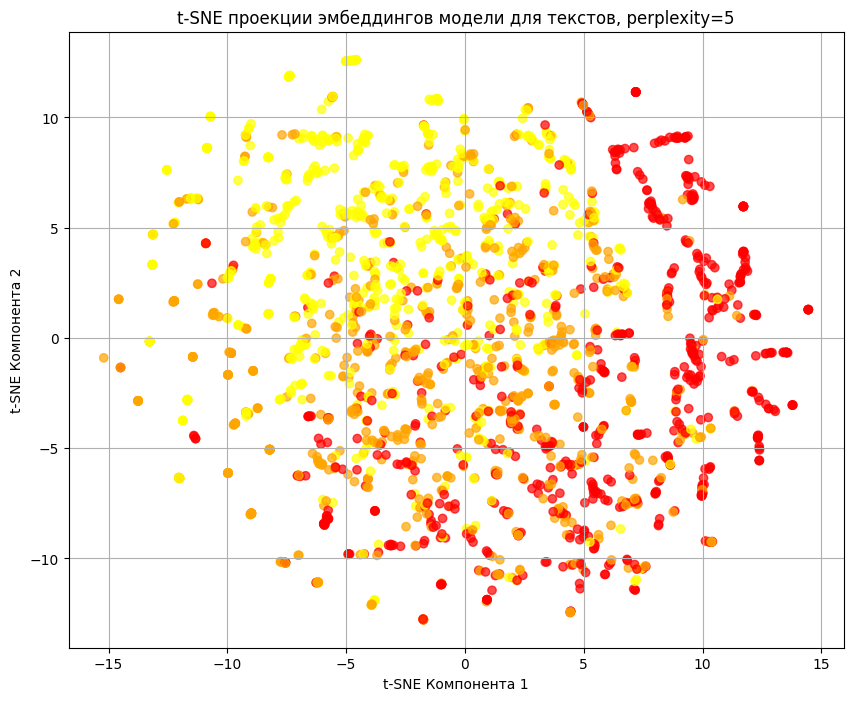

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Original embeddings shape: 2139
Projected embeddings shape: (2139, 2)


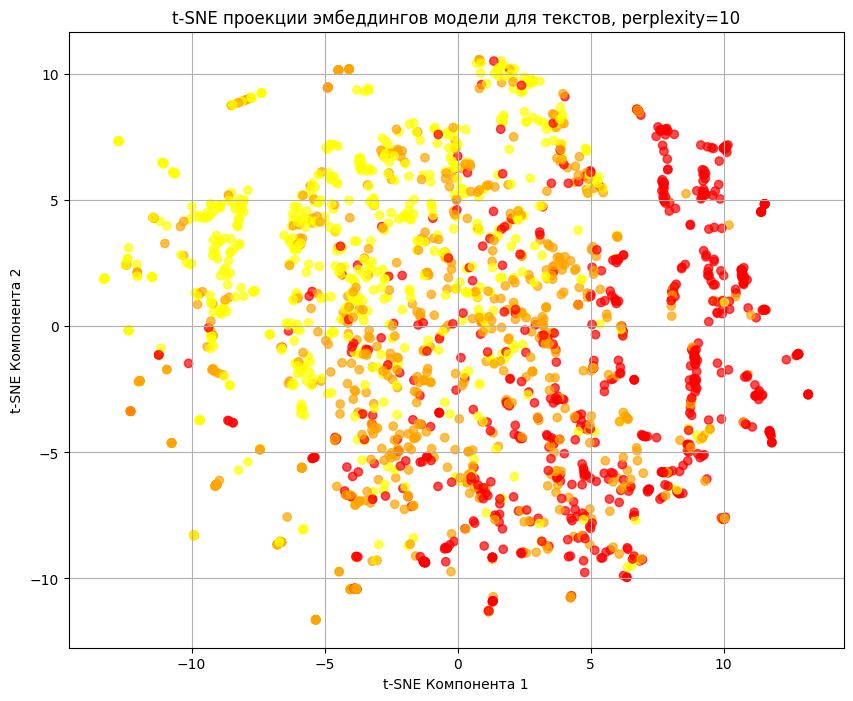

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Original embeddings shape: 2139
Projected embeddings shape: (2139, 2)


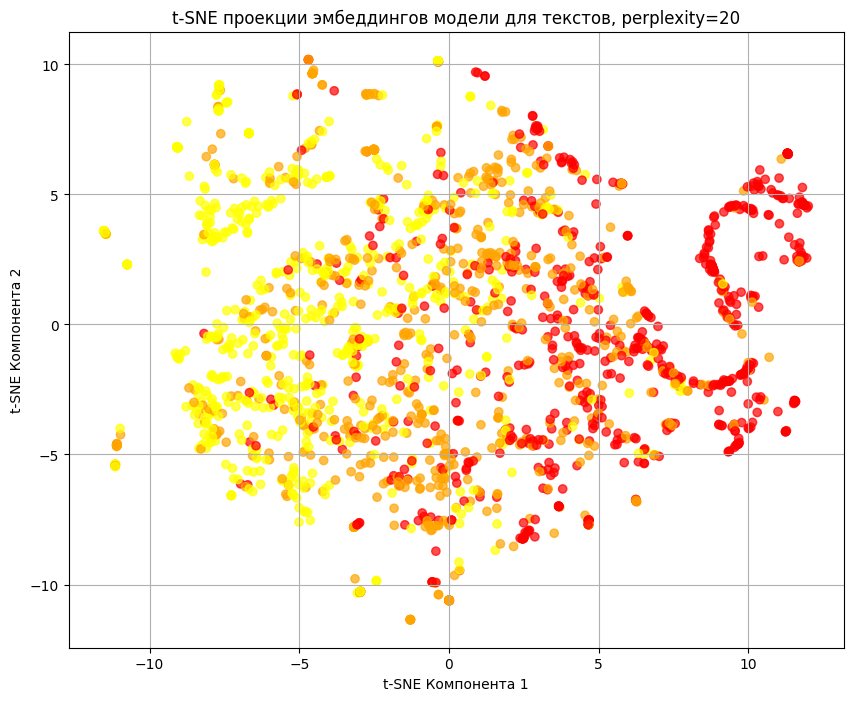

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Original embeddings shape: 2139
Projected embeddings shape: (2139, 2)


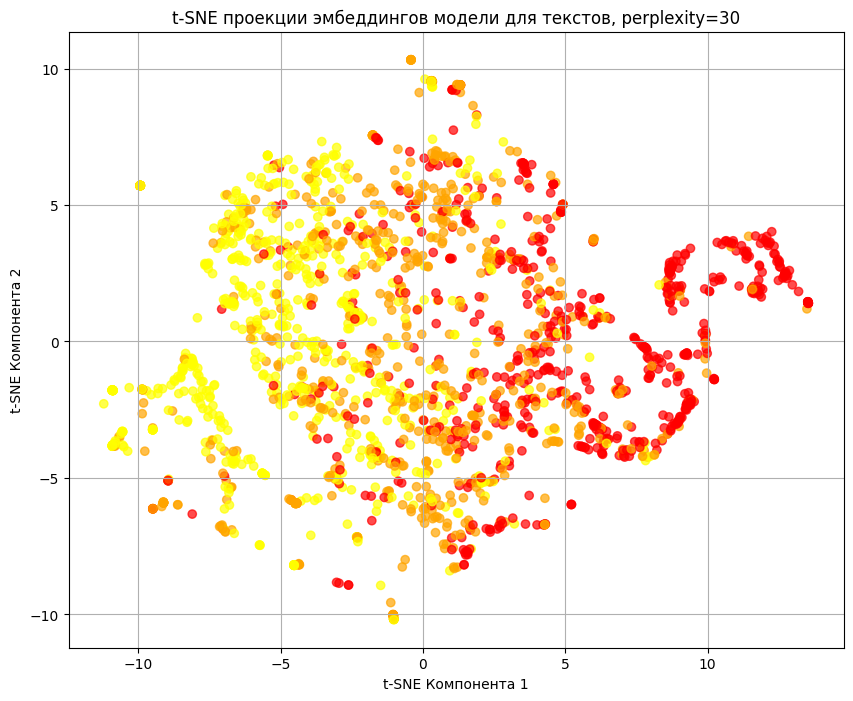

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Original embeddings shape: 2139
Projected embeddings shape: (2139, 2)


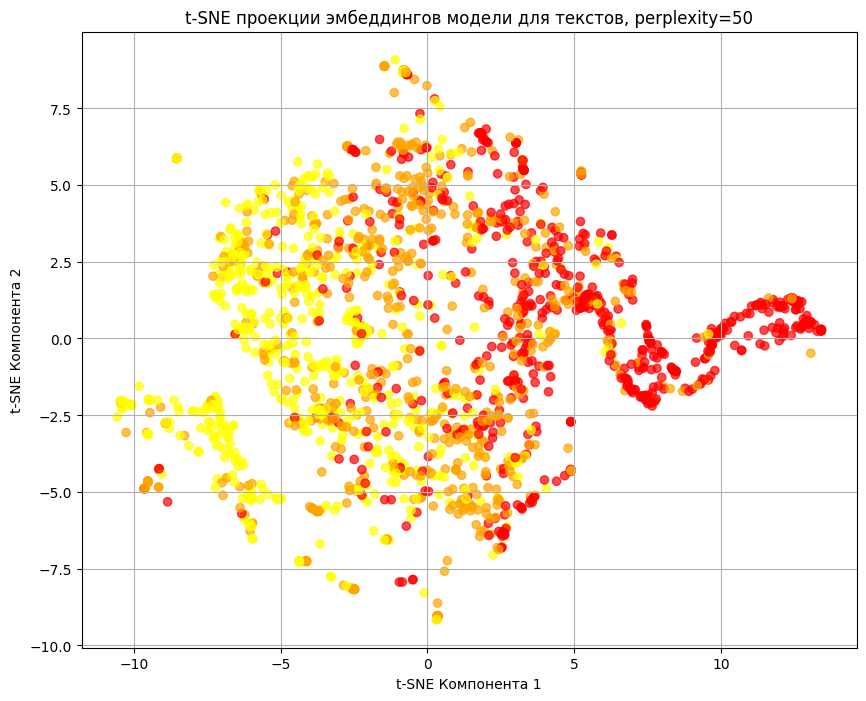

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Initialize t-SNE with 2 components for 2D visualization

for perpexity in [5, 10, 20, 30, 50]:

  tsne = TSNE(n_components=2, random_state=42, perplexity=perpexity, n_iter=300)

  # Fit t-SNE to the embeddings and transform them
  embeddings_2d = tsne.fit_transform(np.array(train_embeddings))

  labels = pd.qcut(train_targets, q=3, labels=['yellow', 'orange', 'red'])

  print(f"Original embeddings shape: {len(train_embeddings)}")
  print(f"Projected embeddings shape: {embeddings_2d.shape}")

  # Visualize the projected embeddings
  plt.figure(figsize=(10, 8))
  plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], color=labels, alpha=0.7)
  plt.title(f't-SNE проекции эмбеддингов модели для текстов, perplexity={perpexity}')
  plt.xlabel('t-SNE Компонента 1')
  plt.ylabel('t-SNE Компонента 2')
  plt.grid(True)
  plt.show()


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
labels2 = pd.qcut(train_prices, q=7, labels=list(range(7)))

In [ ]:
labels2

[3, 4, 4, 3, 6, ..., 3, 6, 4, 2, 5]
Length: 2139
Categories (7, int64): [0 < 1 < 2 < 3 < 4 < 5 < 6]

In [ ]:
for price_group in range(7):
  group_data = [train_embeddings[i] for i in range(len(labels2)) if labels2[i]==price_group]
  corr_m = cosine_similarity(group_data)
  k = corr_m.shape[0]
  corr_sum = np.tril(corr_m, k=-1).sum()
  corr_avg = corr_sum/(k*(k-1)/2.)

  print(f'Группа {price_group}: {corr_avg: .3f}')

Группа 0:  0.719
Группа 1:  0.693
Группа 2:  0.667
Группа 3:  0.704
Группа 4:  0.732
Группа 5:  0.685
Группа 6:  0.698


In [ ]:
corr_m = cosine_similarity(train_embeddings)
k = corr_m.shape[0]
corr_sum = np.tril(corr_m, k=-1).sum()
corr_avg = corr_sum/(k*(k-1)/2.)
corr_avg

np.float32(0.6998873)

In [ ]:
len(embeddings)

10191

In [ ]:
embeddings[0]

array([-0.02425332, -0.00192742,  0.01692664, ..., -0.00811439,
       -0.03091755, -0.02121042], dtype=float32)

In [ ]:
4*1024*10191/1024/1024

39.80859375

In [ ]:
all_embeddings = np.array(embeddings)

In [ ]:
all_embeddings.shape

(10191, 1024)

In [ ]:
with open('ruenRosBERTa_embeddings.npy', 'wb') as f:
    np.save(f, all_embeddings)

### Обучаем 2-ой вариант

In [ ]:
model2 = SBERTRegressor_finetuning(sbert_model)

model2.to(device)
model2.upload_checkpoint(f'./model_checkpoints_1/best_checkpoint.pt', device=device)

for param in model2.sbert_model.pooler.parameters():
    param.requires_grad = False

In [ ]:
train_tk2, train_ms2, train_prices2 = cut_data_by_idx(idx_train_2nd, texts_tokens, texts_masks, prices)

train_2nd_dataset = PriceDataset(np.array(train_tk2), np.array(train_ms2), np.array(train_prices2))

batch_size = 64

train_2nd_dataloader = DataLoader(train_2nd_dataset, batch_size=batch_size, shuffle=True, drop_last=False)

samples_dict = {'train': train_2nd_dataloader, 'val': val_dataloader, 'test': test_dataloader}

In [ ]:
for name, param in model2.named_parameters():
   if param.requires_grad:
    print(name)

regression_head.regression_head1.weight
regression_head.regression_head1.bias
regression_head.regression_head2.weight
regression_head.regression_head2.bias


In [ ]:
import torch.optim as optim

# 1. Define the loss function (Mean Squared Error for regression)
criterion = nn.MSELoss()

# 2. Define the optimizer (Adam)
# Only the regression_head parameters are trainable as sbert_model is frozen
learning_rate = 0.001

params_to_train = [param for param in model2.parameters() if param.requires_grad]

optimizer = optim.Adam(params_to_train, lr=learning_rate)

# 3. Configure the device (CPU/GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model2.to(device)


SBERTRegressor_finetuning(
  (sbert_model): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(98505, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
    

In [ ]:
num_epochs = 30 # Using a higher number of epochs for this small dataset to see convergence
checkpoint_dir = "model_checkpoints_finetuning_head_2"
os.makedirs(checkpoint_dir, exist_ok=True)

metrics_dir = "metrics_finetuning_head_2"
os.makedirs(metrics_dir, exist_ok=True)

training_loop(model2, samples_dict, criterion, optimizer, num_epochs, f'./{metrics_dir}',
                  f'./{checkpoint_dir}', negative_values_penalty=10)

Epoch 30/30: Train Loss: 1538.3200, Train RMSE: 44.8558 | Val Loss: 794.4391, Val RMSE: 25.2490
savepath: model_checkpoints_finetuning_head_2/best_checkpoint.pt
  --> Saved best regression head checkpoint to model_checkpoints_finetuning_head_2/best_checkpoint.pt with Val Loss: 794.4391
Best Epoch Val Loss: 794.4391, Val RMSE: 25.2490
Training finished.
Training metrics saved to 'metrics_finetuning_head_2' folder.


In [ ]:
import os
#model2 = SBERTRegressor_finetuning(sbert_model, n_trainable_layers=1)

model2= SBERTRegressor_finetuning(sbert_model)

model2.to(device)
#model2.upload_checkpoint(f'/content/model_checkpoints_1/best_checkpoint.pt', device=device)
model2.upload_checkpoint(f'/content/model_checkpoints_finetuning_head_2/best_checkpoint.pt', device=device)

# Set the model to evaluation mode after loading weights
model2.eval()
print("Model set to evaluation mode.")

Model set to evaluation mode.


In [ ]:
avg_test_loss, avg_test_rmse, model2_test_res = assess_test(model2, samples_dict['test'], device=device)
avg_test_loss, avg_test_rmse

100%|██████████| 58/58 [01:20<00:00,  1.39s/it]


(1381.5980406136348, 31.90910183150193)

In [ ]:
import matplotlib.pyplot as plt

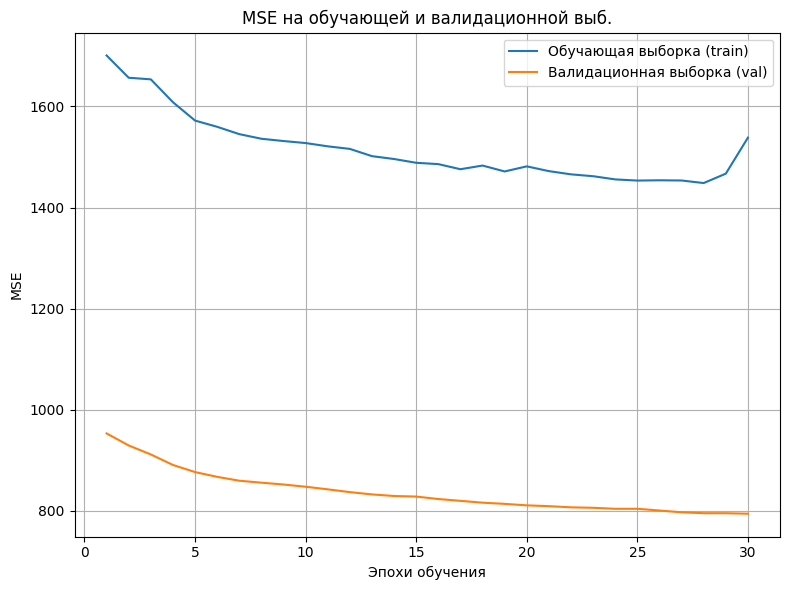

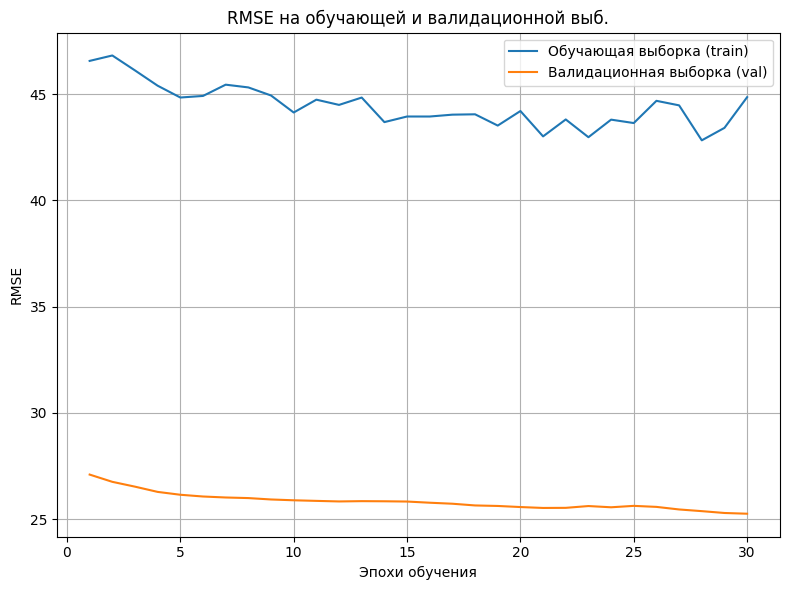

In [ ]:
plot_metrics(metrics_dir)

## Изучаем корреляцию факта и предсказаний

Модель 1

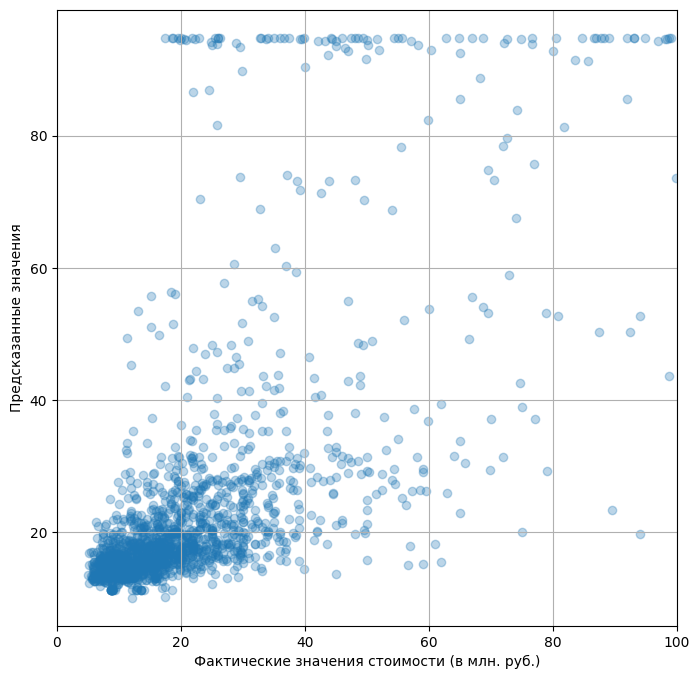

In [ ]:
import matplotlib.pyplot as plt
def plot_scatter(predictions, targets):
  plt.figure(figsize=(8, 8))
  plt.scatter(targets, predictions, alpha=0.3)
  plt.xlabel('Фактические значения стоимости (в млн. руб.)')
  plt.ylabel('Предсказанные значения')
  plt.title('')
  plt.xlim(0, 100) # Set x-axis limit to 100
  plt.grid(True)
  plt.show()

plot_scatter(**model_test_res)

In [ ]:
from scipy.stats import spearmanr, pearsonr

In [ ]:
spearmanr(all_targets, all_predictions), pearsonr(all_targets, all_predictions)

(SignificanceResult(statistic=np.float64(0.6393044934582304), pvalue=np.float64(1.4657623144446484e-36)),
 PearsonRResult(statistic=array([0.46591318], dtype=float32), pvalue=array([6.79705894e-18])))

Модель 2

In [ ]:
def plot_scatter(predictions, targets):
  plt.figure(figsize=(8, 8))
  plt.scatter(targets, predictions, alpha=0.3)
  plt.xlabel('Фактические значения стоимости (в млн. руб.)')
  plt.ylabel('Предсказанные значения')
  plt.title('')
  plt.xlim(0, 100) # Set x-axis limit to 100
  plt.grid(True)
  plt.show()

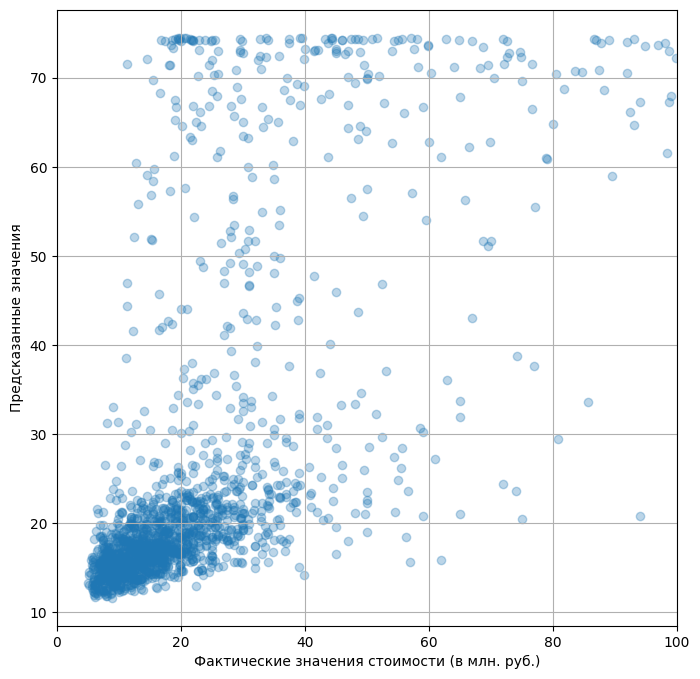

In [ ]:
plot_scatter(**model2_test_res)

In [ ]:
spearmanr(all_targets, all_predictions), pearsonr(all_targets, all_predictions)

(SignificanceResult(statistic=np.float64(0.7095296575570806), pvalue=np.float64(3.949198691315914e-48)),
 PearsonRResult(statistic=array([0.5531592], dtype=float32), pvalue=array([6.34142509e-26])))

In [ ]:
import os
import zipfile

def zip_folder(folder_path, zip_file_obj, arc_prefix=''):
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            # Create an archive name relative to the base folder_path
            arcname = os.path.join(arc_prefix, os.path.relpath(file_path, folder_path))
            zip_file_obj.write(file_path, arcname=arcname)


In [ ]:
import os
import zipfile

def zip_folder(folder_path, zip_file_obj, arc_prefix=''):
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            # Create an archive name relative to the base folder_path
            arcname = os.path.join(arc_prefix, os.path.relpath(file_path, folder_path))
            zip_file_obj.write(file_path, arcname=arcname)

folders_to_zip = [
    'metrics_1',
    'metrics_finetuning_head_2',

    'model_checkpoints_1',
    'model_checkpoints_finetuning_head_2',

]

zip_filename = 'model_and_metrics_embeddings_layer_pooler_finetuning_stage2.zip'

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for folder in folders_to_zip:
        if os.path.exists(folder) and os.path.isdir(folder):
            zip_folder(folder, zipf, arc_prefix=folder)
            print(f"Added folder '{folder}' to '{zip_filename}'")
        else:
            print(f"Warning: Folder '{folder}' not found. Skipping.")

print(f"Successfully created '{zip_filename}'")

Added folder 'metrics_1' to 'model_and_metrics_embeddings_layer_pooler_finetuning_stage2.zip'
Added folder 'metrics_finetuning_head_2' to 'model_and_metrics_embeddings_layer_pooler_finetuning_stage2.zip'
Added folder 'model_checkpoints_1' to 'model_and_metrics_embeddings_layer_pooler_finetuning_stage2.zip'
Added folder 'model_checkpoints_finetuning_head_2' to 'model_and_metrics_embeddings_layer_pooler_finetuning_stage2.zip'
Successfully created 'model_and_metrics_embeddings_layer_pooler_finetuning_stage2.zip'


In [ ]:
from tqdm import tqdm

In [ ]:
embed_folder = 'ruenRoSBERTa_finetuned_layer_pooler_embeddings_v2'
os.mkdir(embed_folder)

In [ ]:
for sample, name in zip([train_dataloader_nonshuffled, train_dataloader_full,
                         test_dataloader, val_dataloader],
                        ['train', 'train_full', 'test', 'val']):

  embeddings, targets = model2.get_embeddings(sample, device=device)
  all_embeddings = np.array(embeddings)

  with open(f'{embed_folder}/{name}_embeddings.npy', 'wb') as f:
      np.save(f, all_embeddings)

100%|██████████| 39/39 [00:54<00:00,  1.40s/it]


In [ ]:
for sample, name in zip([idx_train_ft, idx_train, idx_test, idx_val],
                        ['train', 'train_full', 'test', 'val']):
  all_embeddings = np.array(sample)
  with open(f'{embed_folder}/{name}_index.npy', 'wb') as f:
      np.save(f, all_embeddings)

In [ ]:
folders_to_zip = [
    embed_folder
]

zip_filename = f'{embed_folder}.zip'

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for folder in folders_to_zip:
        if os.path.exists(folder) and os.path.isdir(folder):
            zip_folder(folder, zipf, arc_prefix=folder)
            print(f"Added folder '{folder}' to '{zip_filename}'")
        else:
            print(f"Warning: Folder '{folder}' not found. Skipping.")

Added folder 'ruenRoSBERTa_finetuned_layer_pooler_embeddings_v2' to 'ruenRoSBERTa_finetuned_layer_pooler_embeddings_v2.zip'
